# Анализ данных интернет-магазина

In [1]:
!pip install psycopg2-binary pandas matplotlib

In [2]:
import psycopg2
import pandas as pd
import os

conn = psycopg2.connect(
    host="postgres",
    database=os.getenv("POSTGRES_DB"),
    user=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD")
)


query = "SELECT * FROM orders"
df = pd.read_sql(query, conn)
df.head()


/tmp/ipykernel_143/3065016218.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,id,product_name,category,price,quantity,city,created_at
0,1,Phone,Electronics,500.0,3,Moscow,2026-01-20 13:47:00.144759
1,2,Laptop,Electronics,1000.0,5,Saint Petersburg,2026-01-20 13:47:01.155368
2,3,Phone,Electronics,500.0,5,Kazan,2026-01-20 13:47:02.158013
3,4,Laptop,Electronics,1000.0,1,Novosibirsk,2026-01-20 13:47:03.162060
4,5,Book,Books,15.0,2,Kazan,2026-01-20 13:47:04.172685


## Подготовка данных

In [3]:
df['created_at'] = pd.to_datetime(df['created_at'])
df['total_price'] = df['price'] * df['quantity']

## Общая статистика магазина

In [4]:
total_orders = len(df)
total_revenue = df['total_price'].sum()

print(f"Total orders: {total_orders}")
print(f"Total revenue: {total_revenue:.2f}")

Total orders: 13804
Total revenue: 13486775.00


## Выручка по категориям

In [5]:
revenue_by_category = (
    df.groupby('category')['total_price']
      .sum()
      .sort_values(ascending=False)
)

revenue_by_category

category
Electronics    12535000.0
Fashion          823540.0
Books            128235.0
Name: total_price, dtype: float64

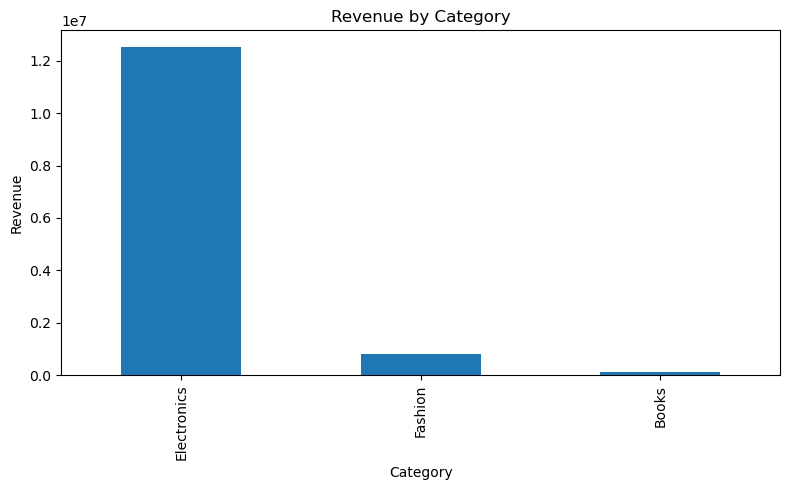

In [6]:
import matplotlib.pyplot as plt

revenue_by_category.plot(kind='bar', figsize=(8,5))
plt.title("Revenue by Category")
plt.ylabel("Revenue")
plt.xlabel("Category")
plt.tight_layout()
plt.show()

## Количество заказов по категориям

In [7]:
orders_by_category = df['category'].value_counts()
orders_by_category

category
Electronics    5536
Fashion        5459
Books          2809
Name: count, dtype: int64

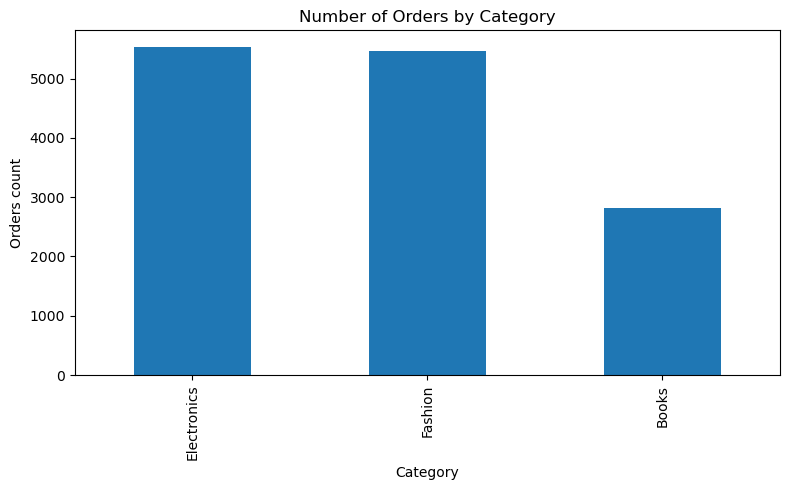

In [8]:
orders_by_category.plot(kind='bar', figsize=(8,5))
plt.title("Number of Orders by Category")
plt.ylabel("Orders count")
plt.xlabel("Category")
plt.tight_layout()
plt.show()

## Средний чек по категориям

In [9]:
avg_order_value = (
    df.groupby('category')['total_price']
      .mean()
      .sort_values(ascending=False)
)

avg_order_value

category
Electronics    2264.270231
Fashion         150.859132
Books            45.651477
Name: total_price, dtype: float64

## Динамика заказов во времени

In [10]:
orders_over_time = (
    df.set_index('created_at')
      .resample('1min')
      .size()
)

orders_over_time.head()

created_at
2026-01-20 13:47:00    60
2026-01-20 13:48:00    59
2026-01-20 13:49:00    59
2026-01-20 13:50:00    60
2026-01-20 13:51:00    60
Freq: T, dtype: int64

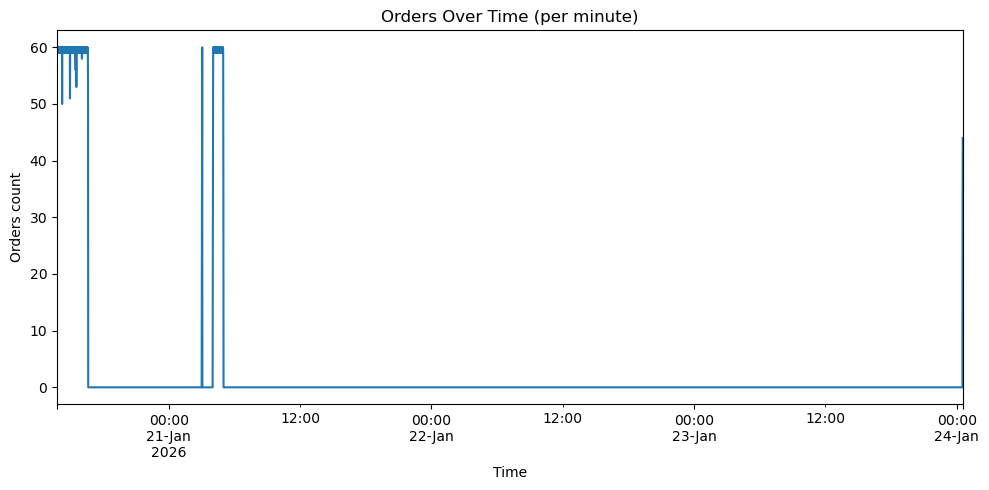

In [11]:
orders_over_time.plot(figsize=(10,5))
plt.title("Orders Over Time (per minute)")
plt.ylabel("Orders count")
plt.xlabel("Time")
plt.tight_layout()
plt.show()